# URBAN INFLUENCES ON THE SEABREEZE
- How do urban landscapes affect the sea breeze and/or wind capacity generation?
- Where in the Sydney region would wind generation assets best be placed?

## 0 Data Preparation
- Identify seabreeze: (method limitation) Despite the identified objects here displaying sea breeze characteristics, it is also clear that sea breezes can be difficult to separate from other frontal objects and circulations near the coast in km-scale model output.
- Method description: https://gmd.copernicus.org/articles/19/933/2026/
- Code: https://zenodo.org/records/17220916?preview_file=andrewbrown31%2Fsea_breeze-v1.1.zip
- Raw data: /g/data/gb02/mjl561/um2nc

In [1]:
import sys
import os
import numpy as np

if not hasattr(np, "in1d"):
    np.in1d = np.isin
    
import xarray as xr
import pandas as pd
from dask.distributed import Client
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [2]:
sys.path.append('/home/561/cx5009/app/')

In [3]:
stats_output_path = "/g/data/up6/cx5009/hackathon/energy2026/Data_identified_seabreeze/"

In [4]:
client = Client()

In [5]:
from sea_breeze import (
load_model_data,
sea_breeze_funcs,
sea_breeze_filters
)

In [6]:
ds = xr.open_dataset("/g/data/gb02/mjl561/um2nc/SY_djf/SY_11p1/CTRL/topog-SY_SY_11p1_CTRL-v1.nc")
ds

/jobfs/171285559.gadi-pbs/ipykernel_2127217/1469722627.py:1: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset("/g/data/gb02/mjl561/um2nc/SY_djf/SY_11p1/CTRL/topog-SY_SY_11p1_CTRL-v1.nc")


<xarray.Dataset> Size: 518kB
Dimensions:                  (latitude: 320, longitude: 400)
Coordinates:
  * latitude                 (latitude) float64 3kB -51.48 -51.37 ... -16.39
  * longitude                (longitude) float64 3kB 129.2 129.3 ... 173.0 173.1
    forecast_period          timedelta64[ns] 8B ...
    forecast_reference_time  datetime64[ns] 8B ...
    time                     datetime64[ns] 8B ...
Data variables:
    topog                    (latitude, longitude) float32 512kB ...
Attributes: (12/35)
    source:                         Data from Met Office Unified Model
    um_version:                     13.5
    geospatial_lat_min:             -51.48
    geospatial_lat_max:             -16.39
    geospatial_lat_resolution:      0.11
    geospatial_lat_resolution_min:  0.109996796
    ...                             ...
    shuffle:                        True
    fletcher32:                     True
    chunksizes:                     [320 400]
    stash_vocabulary:               http://reference.metoffice.gov.uk/um/stash
    stash_references:               /g/data/access/projects/access/umdir/vn13...
    cf_standard_name_table:         cf-standard-name-table.xml.v78

In [7]:
#Time bounds for a single case (using 8 hours of data)
t1 = "2016-01-06 05:00"
t2 = "2016-01-06 12:00"

#Lat lon and height bounds (Perth, Australia). Height bounds chosen approximately as the typical maximum extent of the PBL
lat_slice = slice(-51.48,-16.389999)
lon_slice = slice(129.179993,173.069992)
# hgt_slice = slice(0,4500)

In [8]:
def load_static(exp_season,exp_res,exp_id,lon_slice,lat_slice,chunks="auto"):

    """
    Load static fields for the ACCESS-rAM3 Sydney experiment, stored on the gb02 project.

    Parameters
    ----------
    exp_season : str
        Experiment Season. Must be one of 'SY_djf' or 'SY_jja'.
    exp_res : str
        Experiment Resolution. Must be one of 'SY_1', 'SY_5' or 'SY_11p1'.
    exp_id : str
        Experiment ID. Must be one of 'CTRL' or 'NO-URBAN'.
    lon_slice : slice or array-like
        Slice or indices to restrict longitude domain.
    lat_slice : slice or array-like
        Slice or indices to restrict latitude domain.
    chunks : str or dict, optional
        Chunking for xarray open_mfdataset (default is "auto").

    Returns
    -------
    orog : xarray.DataArray
        Orography field for the selected domain.
    lsm : xarray.DataArray
        Binary land-sea mask (1 for land, 0 for sea) for the selected domain.
    """

    # orog = xr.open_dataset(f"/g/data/gb02/mjl561/um2nc/{exp_season}/{exp_res}/{exp_id}/topog-SY_{exp_res}_{exp_id}-v1.nc",chunks=chunks).\
    #         sel(lat=lat_slice,lon=lon_slice)
    # lsm = xr.open_dataset(f"/g/data/gb02/mjl561/um2nc/{exp_season}/{exp_res}/{exp_id}/lnd_mask-SY_{exp_res}_{exp_id}-v1.nc",chunks=chunks).\
    #         sel(lat=lat_slice,lon=lon_slice)

    orog = xr.open_dataset(f"/g/data/gb02/mjl561/um2nc/{exp_season}/{exp_res}/{exp_id}/topog-SY_{exp_res}_{exp_id}-v1.nc",chunks=chunks)
    orog = orog.rename({
        "latitude": "lat",
        "longitude": "lon"
    })
    
    lsm = xr.open_dataset(f"/g/data/gb02/mjl561/um2nc/{exp_season}/{exp_res}/{exp_id}/lnd_mask-SY_{exp_res}_{exp_id}-v1.nc",chunks=chunks)    
    lsm = lsm.rename({
        "latitude": "lat",
        "longitude": "lon"
    })
    land_mask = xr.where(lsm.lnd_mask != 0, 1, 0)
    
    return orog.topog, land_mask


In [9]:
#Load land sea mask
orog, lsm = load_static('SY_djf','SY_11p1','CTRL',lon_slice,lat_slice)

#Compute coastline angles
angle_ds = load_model_data.get_coastline_angle_kernel(
    lsm,
    R=4,
    latlon_chunk_size=8,
    compute=True,
    smooth=False)

/jobfs/171285559.gadi-pbs/ipykernel_2127217/2674307586.py:34: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  orog = xr.open_dataset(f"/g/data/gb02/mjl561/um2nc/{exp_season}/{exp_res}/{exp_id}/topog-SY_{exp_res}_{exp_id}-v1.nc",chunks=chunks)
/jobfs/171285559.gadi-pbs/ipykernel_2127217/2674307586.py:40: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribut

INFO: Take the weighted mean and convert complex numbers to an angle and magnitude...
INFO: Calculating the sum of the weights...
INFO: Calculating variance...
INFO: Calculating minimum distance to the coast...


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in power
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in power
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


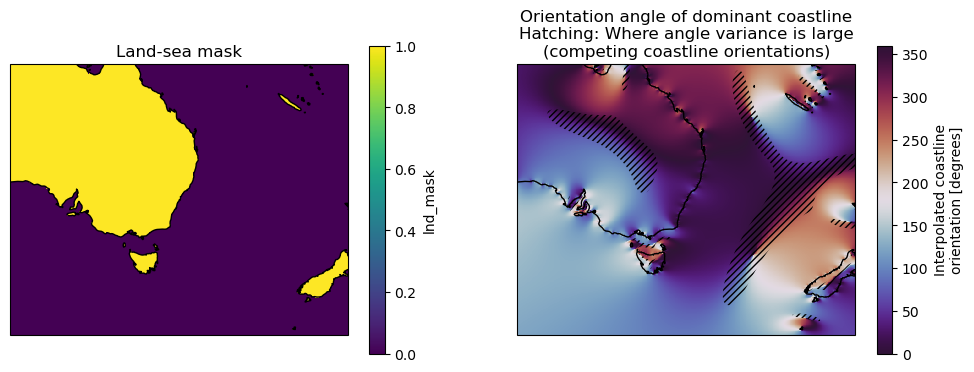

In [10]:
#Plot the model land sea mask and coastline angles
plt.figure(figsize=[12,4])
ax = plt.subplot(1,2,1,projection=ccrs.PlateCarree())
lsm.plot()
ax.coastlines()
plt.title("Land-sea mask")
ax = plt.subplot(1,2,2,projection=ccrs.PlateCarree())
angle_ds.angle_interp.plot(cmap="twilight_shifted",vmin=0,vmax=360)
xr.plot.contourf(angle_ds.variance_interp,levels=[0.,0.5],hatches=["","/////"],colors="none",add_colorbar=False)
ax.coastlines()
plt.title("Orientation angle of dominant coastline\nHatching: Where angle variance is large\n(competing coastline orientations)");


## 1 The character of sea breezes near Sydney
- Dural Cycle of the wind speed, direction, timing, and vertical structure at turbine height

### 1.1 Seasonality & Resolusion (topography/ surface roughness)

## 2 Calculate capacity factors during sea breeze events

## 3 Synthesise and visualise the urban effect